In [2]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer

import seaborn as sns
from sklearn.impute import SimpleImputer

from pathlib import Path

In [3]:
from sklearn import set_config
set_config(transform_output="pandas")

In [4]:
current_path = Path.cwd()

In [5]:
root_path = current_path.parent
data_path = root_path / "data" / "interim" / "clean_train.csv"

In [11]:
data = pd.read_csv(data_path)

In [8]:
pd.set_option("display.max_columns", 100)

In [10]:
data.sample(5)

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,weather,traffic,vehicle_condition,order_type,vehicle_type,multiple_deliveries,is_festival,city_category,time,city,day,month,year,day_of_week,is_weekend,order_time_hour,order_time_of_day,pickup_time,distance,distance_type
11889,33.0,4.6,19.875337,75.316722,19.915337,75.356722,sandstorms,medium,2,buffet,electric_scooter,1.0,no,urban,33,AURG,17,2,2022,Thursday,0,15,afternoon,15.0,6.105310,medium
39830,20.0,4.5,NaN,NaN,NaN,NaN,windy,high,1,drinks,scooter,1.0,no,urban,23,VAD,21,3,2022,Monday,0,13,afternoon,15.0,NaN,NaN
39653,22.0,4.9,NaN,NaN,NaN,NaN,stormy,low,2,buffet,scooter,0.0,no,metropolitian,13,AURG,16,2,2022,Wednesday,0,23,night,10.0,NaN,NaN
24923,32.0,4.8,18.569156,73.774723,18.599156,73.804723,fog,low,0,buffet,motorcycle,1.0,no,metropolitian,28,PUNE,1,4,2022,Friday,0,23,night,15.0,4.596251,short
13528,24.0,4.6,18.534080,73.898520,18.664080,74.028520,stormy,low,1,meal,scooter,0.0,no,NaN,10,PUNE,18,3,2022,Friday,0,0,NaN,10.0,19.916260,very_long


In [13]:
data.shape

(43594, 26)

In [14]:
data.columns

Index(['age', 'ratings', 'restaurant_latitude', 'restaurant_longitude',
       'delivery_latitude', 'delivery_longitude', 'weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle_type',
       'multiple_deliveries', 'is_festival', 'city_category', 'time', 'city',
       'day', 'month', 'year', 'day_of_week', 'is_weekend', 'order_time_hour',
       'order_time_of_day', 'pickup_time_minutes', 'distance',
       'distance_type'],
      dtype='object')

In [349]:
data['time'] = data['time'].str.replace("(min) ", '')

In [350]:
data['time'] = data['time'].astype('float')

In [351]:
col_drop = ['person_id', 'restaurant_latitude',
            'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
           'order_date', 'order_time_hour', 'day'
           ]

data.drop(columns = col_drop, inplace = True)

In [352]:
data.sample(5)

,age,ratings,weather,traffic,vehicle_condition,order_type,vehical_type,multiple_deliveries,is_festival,city_category,time,city,month,day_of_week,is_weekend,pickup_time,order_time_of_day,distance,distance_type
24886,38.0,4.6,cloudy,medium,0.0,buffet,motorcycle,1.0,no,metropolitian,38.0,MYS,3.0,friday,0,10.0,afternoon,13.989450,long
36110,22.0,4.6,stormy,high,0.0,snack,motorcycle,1.0,no,metropolitian,19.0,PUNE,3.0,monday,0,5.0,afternoon,6.128419,medium
7591,32.0,4.6,fog,low,0.0,snack,motorcycle,1.0,no,metropolitian,23.0,BANG,4.0,tuesday,0,15.0,night,9.315745,medium
16127,23.0,4.4,stormy,medium,0.0,snack,motorcycle,1.0,no,metropolitian,37.0,BANG,3.0,sunday,1,5.0,afternoon,20.180911,very_long
21322,36.0,4.7,stormy,low,1.0,meal,motorcycle,1.0,no,urban,22.0,BHP,2.0,sunday,1,15.0,night,NaN,NaN


In [353]:
pd.DataFrame(data.isna().sum())

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
order_type,0
vehical_type,0
multiple_deliveries,993
is_festival,228
city_category,1198


In [354]:
data.duplicated().sum().round()

np.int64(0)

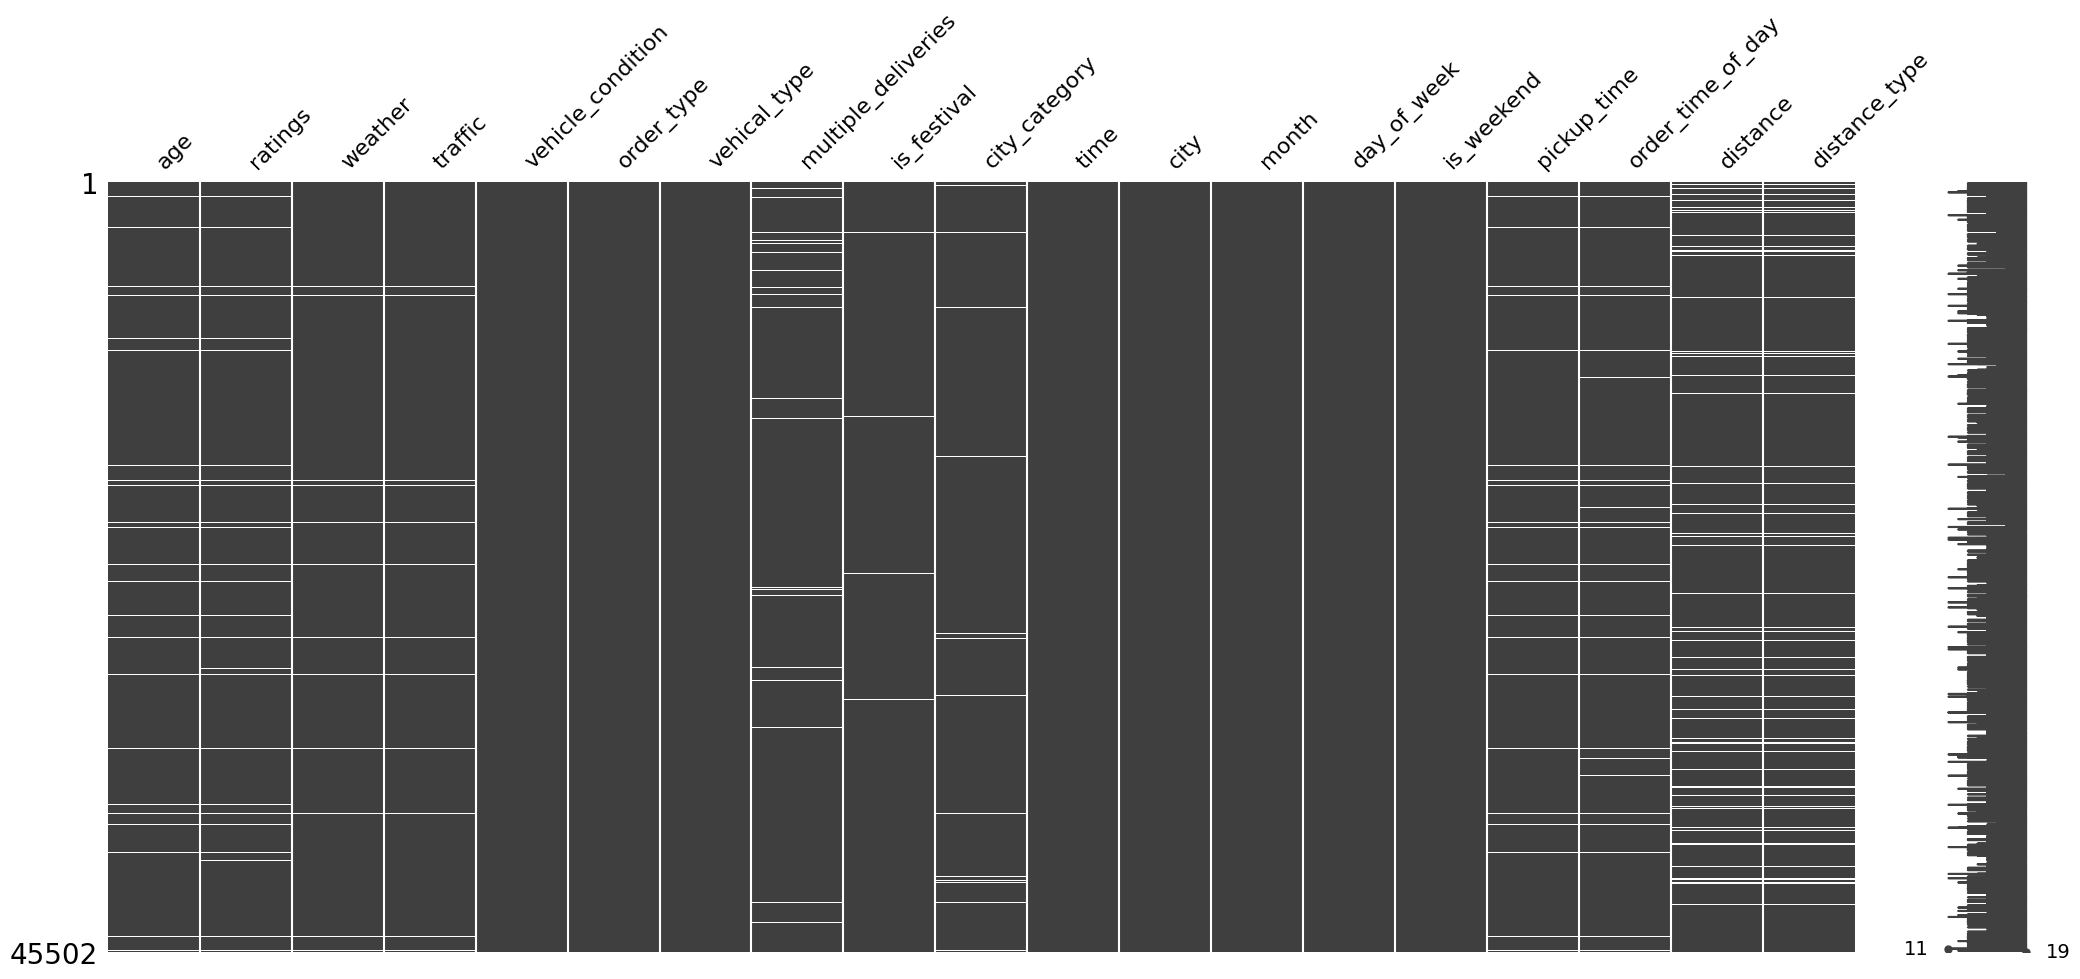

In [355]:
msno.matrix(data)
plt.show()

In [356]:
# colm that have missing value
missing_col = data.isna().any(axis = 0).loc[lambda x: x].index
missing_col

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'is_festival', 'city_category', 'pickup_time', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

### **Data Prep**

In [357]:
temp_data = data.copy().dropna()

In [358]:
X = temp_data.drop(columns = 'time')
y = temp_data['time']

In [359]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [360]:
X_train.shape, X_test.shape

((30156, 18), (7539, 18))

In [361]:
pd.DataFrame(X_train.isna().sum())

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
order_type,0
vehical_type,0
multiple_deliveries,0
is_festival,0
city_category,0


In [362]:
X_train.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'order_type', 'vehical_type', 'multiple_deliveries', 'is_festival',
       'city_category', 'city', 'month', 'day_of_week', 'is_weekend',
       'pickup_time', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [363]:
len(X_train.columns)

18

In [364]:
num_cols = ['age', 'ratings', 'pickup_time', 'distance']

nominal_col = ['weather', 'order_type', 'vehical_type', 'is_festival', 'city_category', 'city', 'order_time_of_day',
              'day_of_week', 'is_weekend', 'month']

oridinal_col = ['traffic', 'distance_type']

In [365]:
len(num_cols + nominal_col + oridinal_col)

16

In [366]:
for col in oridinal_col:
    print(col, X_train[col].unique())

traffic ['jam' 'medium' 'high' 'low']
distance_type ['medium' 'short' 'long' 'very_long']


In [367]:
traffic_order = ['low', 'medium', 'high', 'jam']
distance_type_order = ['medium', 'short', 'long', 'very_long']

In [368]:
preprocessor = ColumnTransformer(
    transformers=[
        ("scale", MinMaxScaler(), num_cols),
        ("nominal_encode", OneHotEncoder(drop = 'first', handle_unknown='ignore', sparse_output=False), nominal_col),
        ("ordinal_encode", OrdinalEncoder(categories=[traffic_order, distance_type_order]), oridinal_col)
    ],
    remainder='passthrough', n_jobs = - 1, force_int_remainder_cols = False,
    verbose_feature_names_out=False
)

preprocessor.set_output(transform='pandas')

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time', 'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'order_type', 'vehical_type',
                                  'is_festival', 'city_category', 'city',
                                  'order_time_of_day', 'day_of_week',
                                  'is_weekend', 'month']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['medium', 'short',
                                                             'long',
                                                             'very_long']]),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [369]:
# Fit on training data and transform
X_train_trans = preprocessor.fit_transform(X_train)

# Transform test data (do NOT fit again)
X_test_trans = preprocessor.transform(X_test)

X_train_trans.sample(5)

,age,ratings,pickup_time,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,order_type_drinks,order_type_meal,order_type_snack,vehical_type_motorcycle,vehical_type_scooter,is_festival_yes,city_category_semi-urban,city_category_urban,city_ALH,city_AURG,city_BANG,city_BHP,city_CHEN,city_COIMB,city_DEH,city_GOA,city_HYD,city_INDO,city_JAP,city_KNP,city_KOC,city_KOL,city_LUDH,city_MUM,city_MYS,city_PUNE,city_RANCHI,city_SUR,city_VAD,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,day_of_week_monday,day_of_week_saturday,day_of_week_sunday,day_of_week_thursday,day_of_week_tuesday,day_of_week_wednesday,is_weekend_1,month_3.0,month_4.0,traffic,distance_type,vehicle_condition,multiple_deliveries
22339,0.947368,0.96,0.0,0.543927,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,1.0,1.0
43417,0.578947,0.96,1.0,0.944680,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,2.0,1.0
34979,0.947368,0.92,0.5,0.641238,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0
45468,0.210526,0.68,0.5,0.561646,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0,2.0,1.0,1.0
44666,0.578947,0.96,0.5,0.466796,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,2.0,0.0,2.0


In [370]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [371]:
pd.DataFrame(pt.lambdas_)

,0
0,0.324461


In [372]:
pd.DataFrame(y_train_pt)

,0
0,2.028672
1,0.554539
2,-2.024267
3,-0.173699
4,0.554539
...,...
30151,0.457580
30152,-0.173699
30153,-1.350937
30154,0.047111


### **Train Initial Baseline Model**

In [373]:
from sklearn.linear_model import LinearRegression

In [374]:
lr = LinearRegression()

lr.fit(X_train_trans, y_train_pt)

LinearRegression()

In [375]:
y_pred_train = lr.predict(X_train_trans)
y_pred_test = lr.predict(X_test_trans)

In [376]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [377]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The Train error is {mean_absolute_error(y_train, y_pred_train_org):.2f} minutes")
print(f"The Test error is {mean_absolute_error(y_test, y_pred_test_org):.2f} minutes")

The Train error is 4.69 minutes
The Test error is 4.67 minutes


In [378]:
print(f"The Train R2 score is {r2_score(y_train, y_pred_train_org):.3f}")
print(f"The Test R2 score is {r2_score(y_test, y_pred_test_org):.3f}")

The Train R2 score is 0.603
The Test R2 score is 0.598


### impute missing value

In [379]:
temp_data = data.copy()

In [380]:
X = temp_data.drop(columns = 'time')
y = temp_data['time']

In [381]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [382]:
print("The size of train data is", X_train.shape)
print("The size of train data is", X_test.shape)

The size of train data is (36401, 18)
The size of train data is (9101, 18)


In [383]:
pd.DataFrame(X_train.isna().sum())

,0
age,1470
ratings,1510
weather,421
traffic,407
vehicle_condition,0
order_type,0
vehical_type,0
multiple_deliveries,795
is_festival,188
city_category,968


In [384]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [385]:
missing_col

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'is_festival', 'city_category', 'pickup_time', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [386]:
X_train.isna().any(axis = 1).mean().round(2) * 100

np.float64(17.0)

### Age

In [393]:
X_train['age'].describe()

count    34931.000000
mean        29.569551
std          5.752869
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

In [394]:
X_train['age'].isna().sum()

np.int64(1470)

In [395]:
age_median = X_train['age'].median

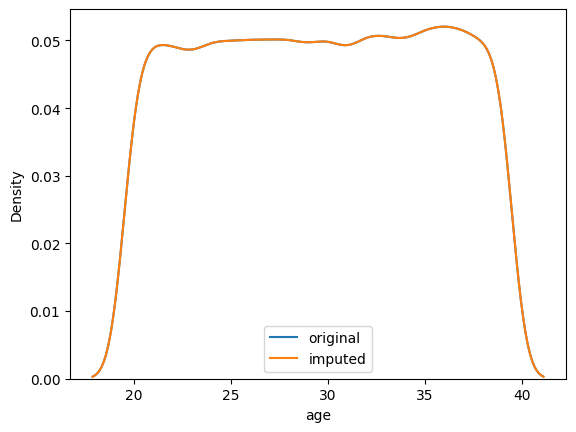

In [398]:
# Convert to numeric (if not already), coerce errors to NaN
X_train['age'] = pd.to_numeric(X_train['age'], errors='coerce')

# Fill NaNs with the median (ensure age_median is a number)
X_train['age_imputed'] = pd.to_numeric(X_train['age_imputed'], errors='coerce').astype(float)

sns.kdeplot(X_train['age'].dropna().astype(float), label='original')
sns.kdeplot(X_train['age_imputed'], label='imputed')
plt.legend()

### Ratings

In [399]:
X_train['ratings'].describe()

count    34891.000000
mean         4.635058
std          0.314049
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

In [400]:
X_train['ratings'].isna().sum()

np.int64(1510)

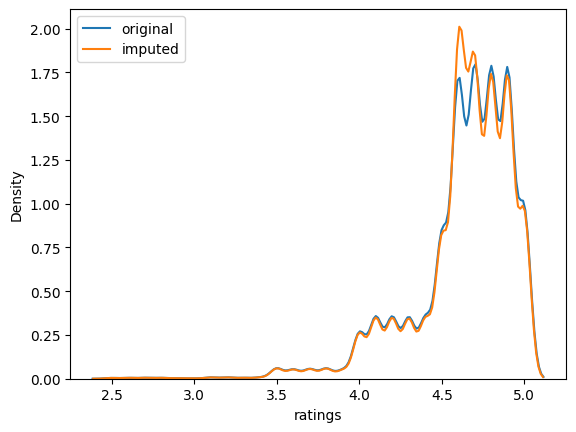

In [401]:
ratings_mean = X_train['ratings'].mean()

sns.kdeplot(X_train['ratings'], label = 'original')
sns.kdeplot(X_train['ratings'].fillna(ratings_mean), label = 'imputed')
plt.legend()
plt.show()

### Weather

In [402]:
X_train['weather'].value_counts()

weather
fog           6160
stormy        6051
cloudy        6033
sandstorms    5958
windy         5928
sunny         5850
Name: count, dtype: int64

In [403]:
X_train['weather'].isna().sum()

np.int64(421)

[]

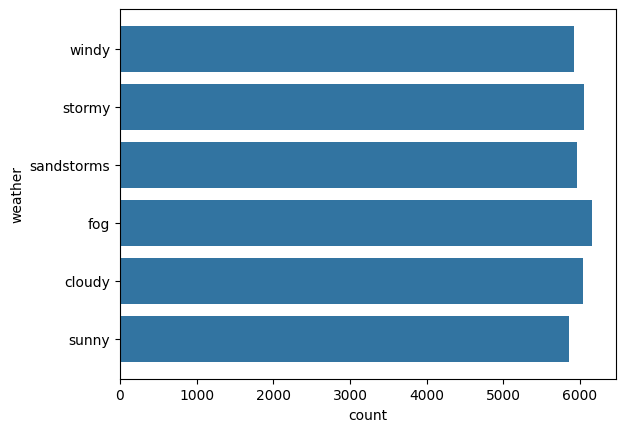

In [404]:
sns.countplot(X_train['weather'])
plt.plot()

In [406]:
from sklearn.impute import MissingIndicator

missing_weather = MissingIndicator()
missing_weather.set_output(transform='pandas')

# Pass as DataFrame, not Series
weather_df = X_train[['weather']]
indicator_df = missing_weather.fit_transform(weather_df)

pd.concat([weather_df, indicator_df], axis=1)

,weather,missingindicator_weather
11029,windy,False
15665,windy,False
14475,stormy,False
29199,windy,False
22514,sandstorms,False
...,...,...
11284,sandstorms,False
44732,cloudy,False
38158,fog,False
860,windy,False


### Traffic

In [407]:
X_train['traffic'].value_counts()

traffic
low       12323
jam       11320
medium     8773
high       3578
Name: count, dtype: int64

In [408]:
X_train['traffic'].isna().sum()

np.int64(407)

[]

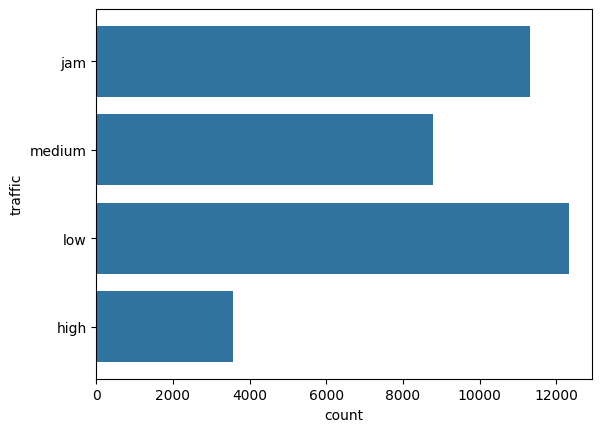

In [409]:
sns.countplot(X_train['traffic'])
plt.plot()

In [410]:
missing_col

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'is_festival', 'city_category', 'pickup_time', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

### Multiple Deliveries

In [411]:
X_train['multiple_deliveries'].value_counts()

multiple_deliveries
1.0    22487
0.0    11252
2.0     1599
3.0      268
Name: count, dtype: int64

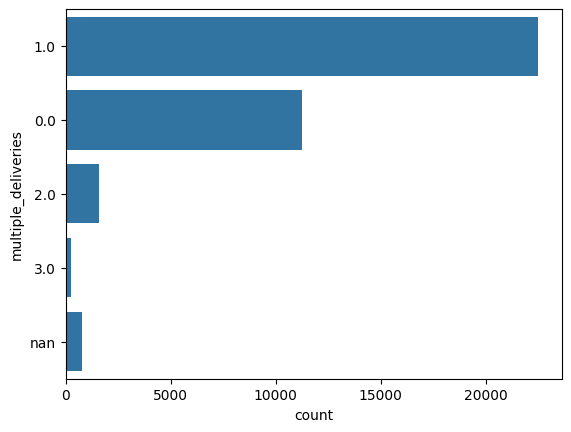

In [412]:
sns.countplot(X_train['multiple_deliveries'].apply(str))
plt.show()

In [413]:
X_train['multiple_deliveries'].isna().sum()

np.int64(795)

In [414]:
multiple_deliveries_mode = X_train['multiple_deliveries'].mode()[0]

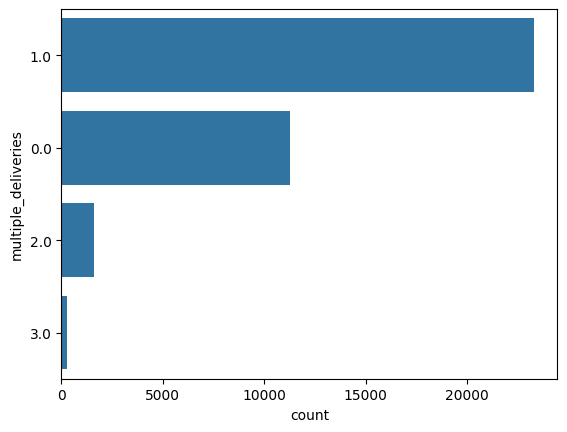

In [415]:
sns.countplot(X_train['multiple_deliveries'].fillna(multiple_deliveries_mode).apply(str))
plt.show()

In [416]:
X_train['multiple_deliveries'].isna().sum()

np.int64(795)

### Festival

In [417]:
X_train['is_festival'].value_counts()

is_festival
no     35474
yes      739
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='is_festival'>

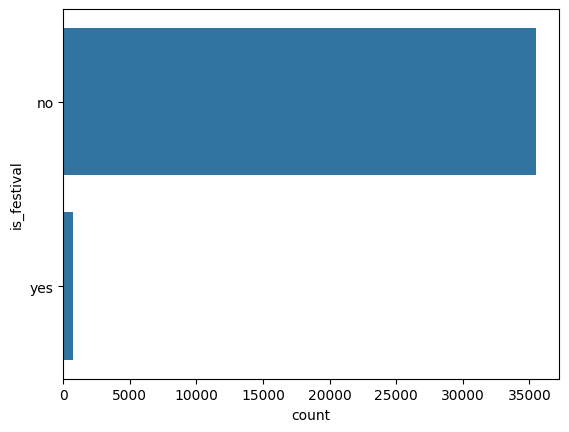

In [418]:
sns.countplot(X_train['is_festival'])

In [419]:
X_train['is_festival'].isna().sum()

np.int64(188)

In [420]:
festival_mode = X_train['is_festival'].mode()[0]

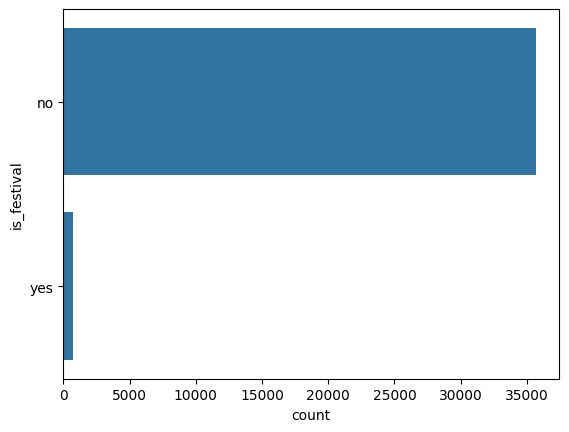

In [421]:
sns.countplot(X_train['is_festival'].fillna(festival_mode))
plt.show()

### City type

In [422]:
X_train['city_category'].value_counts()

city_category
metropolitian    27245
urban             8058
semi-urban         130
Name: count, dtype: int64

In [423]:
X_train['city_category'].isna().sum()

np.int64(968)

<Axes: xlabel='count', ylabel='city_category'>

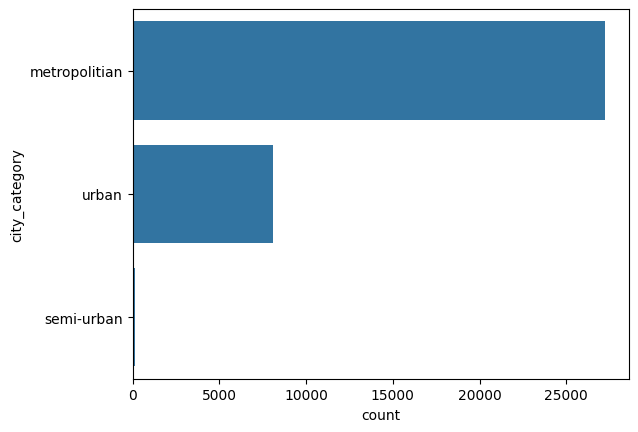

In [424]:
sns.countplot(X_train['city_category'])

In [425]:
city_type_mode = X_train['city_category'].mode()[0]

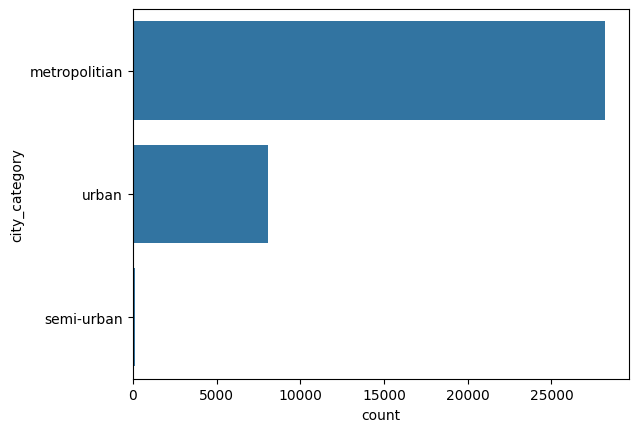

In [426]:
sns.countplot(X_train['city_category'].fillna(city_type_mode))
plt.show()

In [427]:
missing_col

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'is_festival', 'city_category', 'pickup_time', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

### pickup time minutes

In [428]:
X_train['pickup_time'].describe()

count    35103.000000
mean         9.998718
std          4.082279
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: pickup_time, dtype: float64

In [429]:
X_train['pickup_time'].isna().sum()

np.int64(1298)

In [430]:
pickup_time_median = X_train['pickup_time'].median()

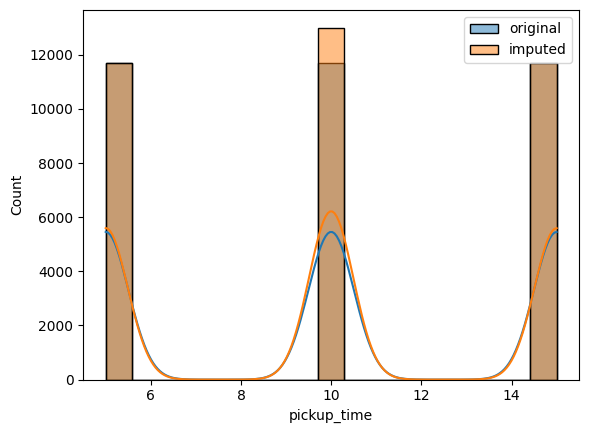

In [431]:
sns.histplot(X_train['pickup_time'], kde = True, label = 'original')
sns.histplot(X_train['pickup_time'].fillna(pickup_time_median), kde = True, label = 'imputed')
plt.legend()

### Order time of day

In [432]:
X_train['order_time_of_day'].value_counts()

order_time_of_day
night        10994
evening      10906
morning       6883
afternoon     5972
Name: count, dtype: int64

In [433]:
X_train['order_time_of_day'].isna().sum()

np.int64(1646)

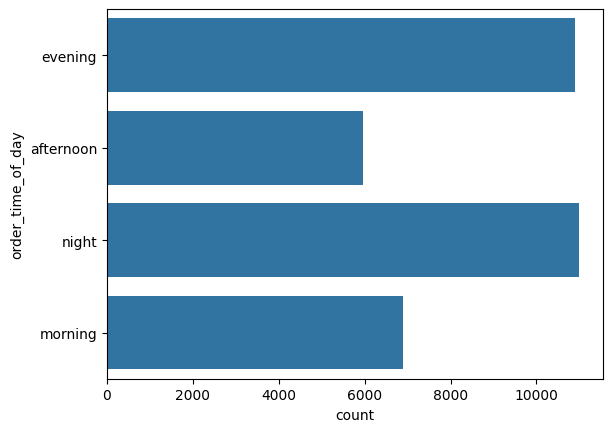

In [434]:
sns.countplot(X_train['order_time_of_day'])
plt.show()

In [435]:
X_train[X_train['order_time_of_day'].isna()]

,age,ratings,weather,traffic,vehicle_condition,order_type,vehical_type,multiple_deliveries,is_festival,city_category,city,month,day_of_week,is_weekend,pickup_time,order_time_of_day,distance,distance_type,age_imputed
14475,NaN,NaN,stormy,low,2.0,meal,scooter,1.0,no,metropolitian,MYS,3.0,saturday,1,NaN,NaN,1.554563,short,NaN
21916,20.0,2.8,sunny,low,2.0,drinks,scooter,1.0,no,metropolitian,JAP,3.0,wednesday,0,10.0,NaN,10.427236,long,20.0
34951,28.0,5.0,fog,low,2.0,snack,motorcycle,1.0,no,metropolitian,HYD,3.0,sunday,1,15.0,NaN,16.903757,very_long,28.0
8165,NaN,NaN,NaN,NaN,3.0,meal,scooter,1.0,no,metropolitian,KOL,2.0,wednesday,0,NaN,NaN,19.673431,very_long,NaN
23469,NaN,NaN,sunny,jam,0.0,buffet,motorcycle,1.0,no,metropolitian,COIMB,4.0,tuesday,0,NaN,NaN,4.674220,short,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33827,NaN,NaN,NaN,NaN,3.0,drinks,electric_scooter,1.0,no,urban,GOA,2.0,monday,0,NaN,NaN,NaN,NaN,NaN
22403,NaN,NaN,sunny,low,0.0,snack,motorcycle,1.0,no,urban,INDO,3.0,monday,0,NaN,NaN,3.024981,short,NaN
21518,NaN,NaN,stormy,jam,1.0,meal,scooter,0.0,no,urban,MYS,4.0,saturday,1,NaN,NaN,17.097973,very_long,NaN
22002,25.0,5.0,sunny,low,1.0,meal,scooter,1.0,no,metropolitian,LUDH,2.0,tuesday,0,5.0,NaN,8.789430,medium,25.0


### distance

In [436]:
X_train['distance'].describe()

count    33470.000000
mean         9.738154
std          5.608401
min          1.465067
25%          4.657672
50%          9.193421
75%         13.681057
max         20.969489
Name: distance, dtype: float64

In [437]:
X_train['distance'].isna().sum()

np.int64(2931)

In [438]:
distance_mean = X_train['distance'].mean()

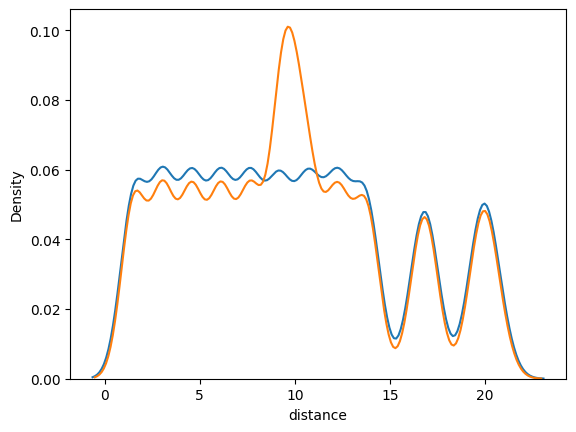

In [439]:
sns.kdeplot(X_train['distance'], label = 'original')
sns.kdeplot(X_train['distance'].fillna(distance_mean), label = 'imputed')
plt.show()

In [440]:
missing_col

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'is_festival', 'city_category', 'pickup_time', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

### distance type

In [441]:
X_train['distance_type'].value_counts()

distance_type
long         9025
short        8998
medium       8993
very_long    6454
Name: count, dtype: int64

In [442]:
X_train['distance_type'].isna().sum()

np.int64(2931)

<Axes: xlabel='count', ylabel='distance_type'>

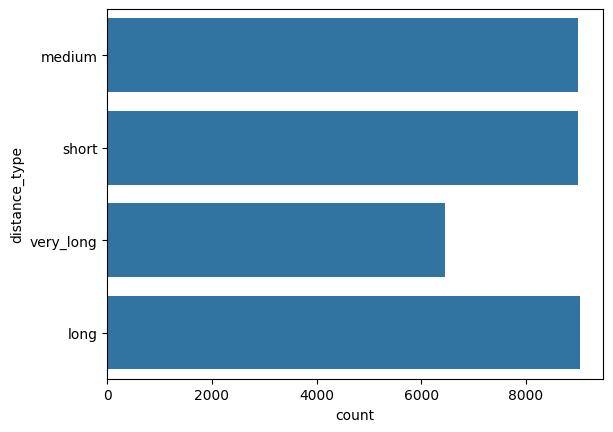

In [443]:
sns.countplot(X_train['distance_type'])

### Imputation pipeline

In [462]:
nominal_col

['weather',
 'order_type',
 'vehical_type',
 'is_festival',
 'city_category',
 'city',
 'order_time_of_day',
 'day_of_week',
 'is_weekend',
 'month']

In [463]:
X_train.isna().sum()

age                    1470
ratings                1510
weather                 421
traffic                 407
vehicle_condition         0
order_type                0
vehical_type              0
multiple_deliveries     795
is_festival             188
city_category           968
city                      0
month                     0
day_of_week               0
is_weekend                0
pickup_time            1298
order_time_of_day      1646
distance               2931
distance_type          2931
age_imputed            1470
dtype: int64

In [464]:
features_to_fill_mode = ['multiple_deliveries', "is_festival", 'city_category']
features_to_fill_missing = [col for col in nominal_col if col not in features_to_fill_mode]

features_to_fill_missing

['weather',
 'order_type',
 'vehical_type',
 'city',
 'order_time_of_day',
 'day_of_week',
 'is_weekend',
 'month']

In [465]:
simple_imputer = ColumnTransformer(
    transformers=[
        ('mode_impute', SimpleImputer(strategy='most_frequent'), features_to_fill_mode),
        ('missing_imputer', SimpleImputer(strategy='constant', fill_value='missing'), features_to_fill_missing)
    ],
    remainder='passthrough', n_jobs = -1, force_int_remainder_cols = False, verbose_feature_names_out = False
)

simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_impute',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['multiple_deliveries', 'is_festival',
                                  'city_category']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['weather', 'order_type', 'vehical_type',
                                  'city', 'order_time_of_day', 'day_of_week',
                                  'is_weekend', 'month'])],
                  verbose_feature_names_out=False)

In [469]:
simple_imputer.fit_transform(X_train)

,multiple_deliveries,is_festival,city_category,weather,order_type,vehical_type,city,order_time_of_day,day_of_week,is_weekend,month,age,ratings,traffic,vehicle_condition,pickup_time,distance,distance_type,age_imputed
11029,1.0,no,metropolitian,windy,snack,electric_scooter,MUM,evening,wednesday,0,3.0,26.0,4.7,jam,2.0,10.0,9.177684,medium,26.0
15665,1.0,no,metropolitian,windy,drinks,motorcycle,SUR,afternoon,thursday,0,3.0,21.0,4.9,medium,2.0,5.0,6.081536,medium,21.0
14475,1.0,no,metropolitian,stormy,meal,scooter,MYS,missing,saturday,1,3.0,NaN,NaN,low,2.0,NaN,1.554563,short,NaN
29199,1.0,no,metropolitian,windy,buffet,motorcycle,JAP,evening,monday,0,4.0,32.0,4.7,medium,0.0,15.0,20.852271,very_long,32.0
22514,0.0,no,urban,sandstorms,meal,scooter,RANCHI,night,wednesday,0,3.0,34.0,4.9,jam,1.0,5.0,9.056096,medium,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.0,no,metropolitian,sandstorms,meal,scooter,COIMB,evening,monday,0,4.0,29.0,4.7,jam,2.0,5.0,12.464367,long,29.0
44732,0.0,no,urban,cloudy,buffet,motorcycle,SUR,morning,wednesday,0,3.0,36.0,4.8,low,0.0,10.0,1.520432,short,36.0
38158,0.0,no,metropolitian,fog,buffet,scooter,BHP,evening,thursday,0,2.0,36.0,4.4,jam,1.0,10.0,NaN,NaN,36.0
860,1.0,no,metropolitian,windy,meal,scooter,CHEN,afternoon,saturday,1,3.0,25.0,4.9,medium,2.0,5.0,7.760938,medium,25.0


In [470]:
simple_imputer.fit_transform(X_train).isna().sum()

multiple_deliveries       0
is_festival               0
city_category             0
weather                   0
order_type                0
vehical_type              0
city                      0
order_time_of_day         0
day_of_week               0
is_weekend                0
month                     0
age                    1470
ratings                1510
traffic                 407
vehicle_condition         0
pickup_time            1298
distance               2931
distance_type          2931
age_imputed            1470
dtype: int64

In [475]:
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors = 5)

In [476]:
num_cols = ['age', 'ratings', 'pickup_time', 'distance']

nominal_cat_cols = ['weather', 'order_type', 'vehical_type',
                   'is_festival', 'city_category', 'city',
                    'month', 'day_of_week', 'is_weekend',
                    'order_time_of_day'
                   ]

ordinal_cat_col = ['traffic', 'distance']

In [477]:
traffic_order = ['low', 'medium', 'high', 'jam']

distance_type_order = ['short', 'medium', 'long', 'very_long']

In [478]:
for col in oridinal_col:
    print(col, X_train[col].unique())

traffic ['jam' 'medium' 'low' 'high' nan]
distance_type ['medium' 'short' 'very_long' 'long' nan]


In [481]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scale', MinMaxScaler(), num_cols),
        ('nominal_encode', OneHotEncoder(drop = 'first', handle_unknown='ignore', sparse_output=False), nominal_cat_cols),
        ('ordinal_encode', OrdinalEncoder(categories=[traffic_order, distance_type_order], 
                                          encoded_missing_value = -999,
                                          handle_unknown='use_encoded_value', 
                                          unknown_value=-1), ordinal_cat_col)
    ],
    remainder='passthrough', n_jobs = -1, force_int_remainder_cols = False,
    verbose_feature_names_out=False
)

preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time', 'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'order_type', 'vehical_type',
                                  'is_festival', 'city_category', 'city',
                                  'month', 'day_of_week', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance'])],
                  verbose_feature_names_out=False)

In [484]:
preprocessor.fit_transform(X_train)

ValueError: could not convert string to float: 'short'

In [485]:
preprocessor.fit_transform(X_train).isna().sum().loc[lambda ser : ser.ge(1)]

ValueError: could not convert string to float: 'short'

In [489]:
from sklearn.pipeline import Pipeline

processing_pipeline = Pipeline(steps = [
    ('simple_impute', simple_imputer),
    ('preprocess', preprocessor),
    ('knn_imputer', knn_imputer)
])

processing_pipeline

Pipeline(steps=[('simple_impute',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('mode_impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['multiple_deliveries',
                                                   'is_festival',
                                                   'city_category']),
                                                 ('missing_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'),
                                                  ['weather', 'order_type',
                                                   'vehical_ty...
                                                   'city_category', 'city',
                                                   'month', 'day_of_week',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic', 'distance'])],
                                   verbose_feature_names_out=False)),
                ('knn_imputer', KNNImputer())])

In [490]:
processing_pipeline.fit_transform(X_train)

ValueError: could not convert string to float: 'short'

In [492]:
lr = LinearRegression()

model_pipe = Pipeline(steps = [
        ("preprocessing", processing_pipeline),
    ('model', lr)
])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_impute',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_impute',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'is_festival',
                                                                    'city_category']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['...
                                                                    'is_weekend',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [493]:
model_pipe.fit(X_train, y_train_pt)

ValueError: could not convert string to float: 'short'

In [494]:
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

In [495]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train, y_pred_train): .2f"} minutes")
print(f"The test error is {mean_absolute_error(y_test, y_pred_test): .2f"} minutes")

In [ ]:
print(f"The train error is {r2_score(y_train, y_pred_train): .2f"} minutes")
print(f"The test error is {r2_score(y_test, y_pred_test): .2f"} minutes")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state= 42, n_jobs = -1)

model_pipe = Pipeline(steps = [
    ("preprocessing", processing_pipeline),
    ("model", rf)
])

model_pipe

In [496]:
model_pipe.fit(X_train, y_train_pt.values.ravel())

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [ ]:
y_pred_train = model_pipe.predict(X_train)

y_pred_test = model_pipe.predict(X_test)

In [ ]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error{y_train, y_pred_train_org}:2f)")
print(f"The test error is {mean_absolute_error{y_test, y_pred_test_org}:2f)")

In [ ]:
print(f"The train error is {r2_score{y_train, y_pred_train_org}:2f)")
print(f"The test error is {r2_score{y_test, y_pred_test_org}:2f)")